<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana8/Semana8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# SEMANA 8 - LABORATÓRIO: ANÁLISE EXPLORATÓRIA E PRÉ-PROCESSAMENTO AVANÇADO
# Dataset: Preço de Carros Usados (MSRP Dataset - 11.914 linhas)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Configuração estética global dos gráficos (Visual limpo e moderno)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [ ]:
print("========== ETAPA DE LEITURA DOS DADOS ==========")

# ------------------------------------------------------------------------------
# OPÇÃO A: Ler diretamente da Internet (GitHub RAW do projeto)
# ------------------------------------------------------------------------------
url_github = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
df = pd.read_csv(url_github)
print("Dados importados com sucesso DIRETAMENTE do GitHub!")

# ------------------------------------------------------------------------------
# OPÇÃO B: Ler um arquivo CSV local (Descomente as duas linhas abaixo se preferir)
# ------------------------------------------------------------------------------
# # Certifique-se de baixar o arquivo 'data.csv' e colocá-lo na mesma pasta deste script
# df = pd.read_csv('data.csv')
# print("Dados importados com sucesso do arquivo LOCAL!")
# ------------------------------------------------------------------------------

========== ETAPA DE LEITURA DOS DADOS ==========
Dados importados com sucesso DIRETAMENTE do GitHub!


## Dia 1


=== INICIANDO DIA 1: ANÁLISE EXPLORATÓRIA ===

1. Dimensões do Dataset: 11914 linhas e 16 colunas.

2. Visualizando a estrutura inicial dos dados:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500



3. Resumo Estatístico das Variáveis Numéricas:


,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06



Gerando Gráfico 1: Top 10 Marcas Mais Frequentes...


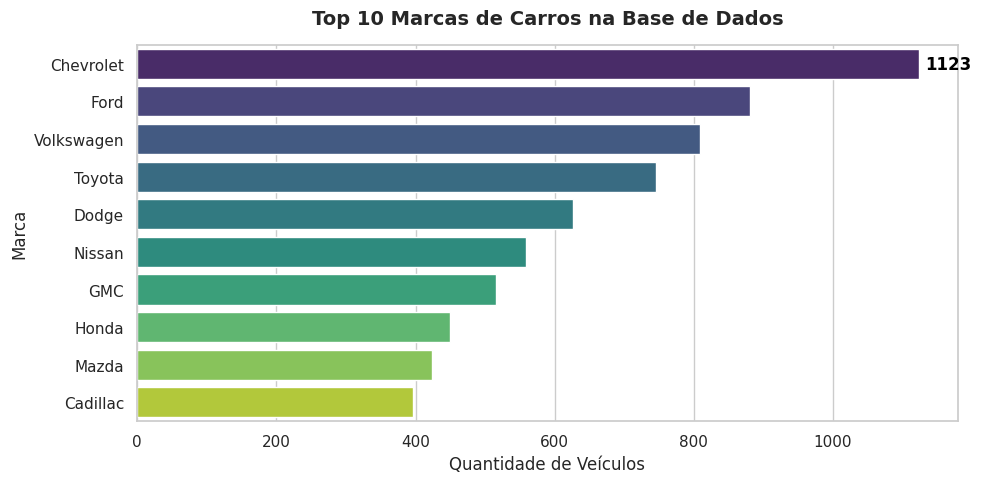


Gerando Gráfico 2: Relação entre Potência e Preço...


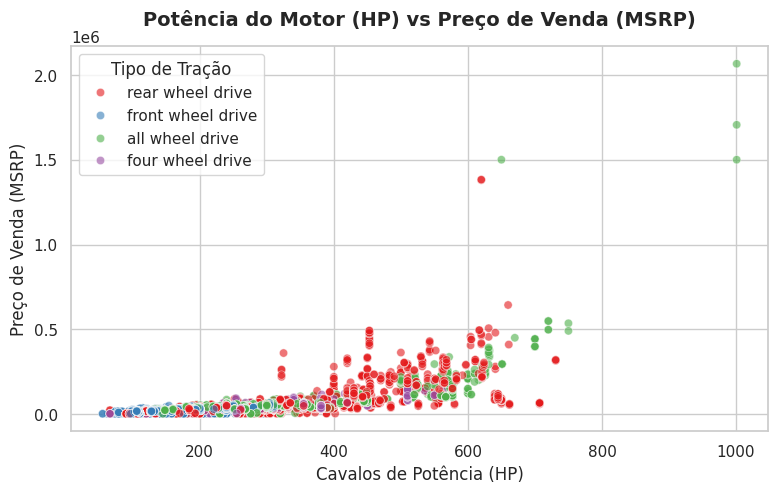


Gerando Gráfico 3: Distribuição Geral de Preços...


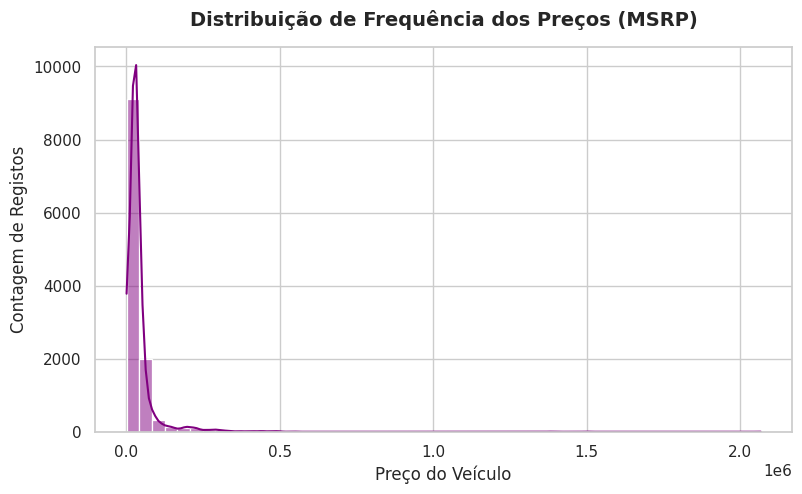

In [ ]:
# ==================== DIA 1: INVESTIGAÇÃO (EDA) ====================
print("\n=== INICIANDO DIA 1: ANÁLISE EXPLORATÓRIA ===")

print(f"\n1. Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")

print("\n2. Visualizando a estrutura inicial dos dados:")
display(df.head())

print("\n3. Resumo Estatístico das Variáveis Numéricas:")
display(df.describe())

# --- GRÁFICO 1: TOP 10 MARCAS (Com valores nas barras e correção de palette) ---
print("\nGerando Gráfico 1: Top 10 Marcas Mais Frequentes...")
fig, ax = plt.subplots(figsize=(10, 5))
top_marcas = df['Make'].value_counts().head(10)

# CORREÇÃO SEABORN: Atribuindo y ao hue e desativando a legenda redundante
sns.barplot(
    x=top_marcas.values,
    y=top_marcas.index,
    hue=top_marcas.index,
    palette='viridis',
    legend=False,
    ax=ax
)
# VALORIZAÇÃO: Adiciona os números exatos à frente de cada barra de forma automática
ax.bar_label(ax.containers[0], fmt='%d', padding=5, color='black', fontweight='bold')
plt.title("Top 10 Marcas de Carros na Base de Dados", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Quantidade de Veículos", fontsize=12)
plt.ylabel("Marca", fontsize=12)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: POTÊNCIA VS PREÇO (Com segmentação por tração) ---
print("\nGerando Gráfico 2: Relação entre Potência e Preço...")
plt.figure(figsize=(9, 5))
# VALORIZAÇÃO: Separamos os pontos por cores baseadas no tipo de tração (Driven_Wheels)
sns.scatterplot(
    data=df,
    x='Engine HP',
    y='MSRP',
    hue='Driven_Wheels',
    palette='Set1',
    alpha=0.6
)
plt.title("Potência do Motor (HP) vs Preço de Venda (MSRP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cavalos de Potência (HP)", fontsize=12)
plt.ylabel("Preço de Venda (MSRP)", fontsize=12)
plt.legend(title="Tipo de Tração")
plt.show()

# --- GRÁFICO 3 (NOVO!): HISTOGRAMA DE DISTRIBUIÇÃO DE PREÇOS ---
print("\nGerando Gráfico 3: Distribuição Geral de Preços...")
plt.figure(figsize=(9, 5))
# VALORIZAÇÃO: Mostra a curva de densidade (KDE) para explicar assimetria estatística
sns.histplot(data=df, x='MSRP', bins=50, kde=True, color='purple')
plt.title("Distribuição de Frequência dos Preços (MSRP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Preço do Veículo", fontsize=12)
plt.ylabel("Contagem de Registos", fontsize=12)
plt.show()

## Dia 2


=== INICIANDO DIA 2: LIMPEZA DOS DADOS ===

1. Contagem de Valores Nulos (NaN) ANTES do tratamento:
Engine Fuel Type       3
Engine HP             69
Engine Cylinders      30
Number of Doors        6
Market Category     3742
dtype: int64

2. Contagem de Valores Nulos (NaN) DEPOIS do tratamento: Tudo zerado!
Series([], dtype: int64)
Quantidade de linhas apos remoção de nulos 11905
         Make     Model  Year             Engine Fuel Type  Engine HP  \
11        BMW  1 Series  2013  premium unleaded (required)      230.0   
14        BMW  1 Series  2013  premium unleaded (required)      230.0   
17       Audi       100  1992             regular unleaded      172.0   
18       Audi       100  1992             regular unleaded      172.0   
20       Audi       100  1992             regular unleaded      172.0   
...       ...       ...   ...                          ...        ...   
11604   Volvo      XC60  2017             regular unleaded      240.0   
11707  Suzuki       XL7  2008   

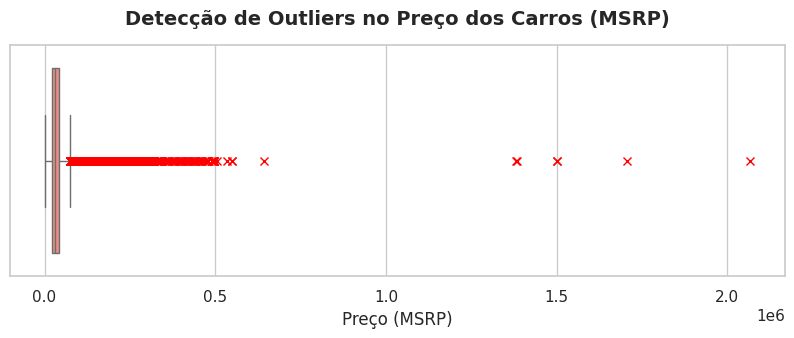


Base filtrada para carros normais (Abaixo de R$ 250.000). Novo tamanho: 11025 linhas.

Gerando Gráfico 5: Preço por Tamanho do Veículo (Sem Outliers extremos)...


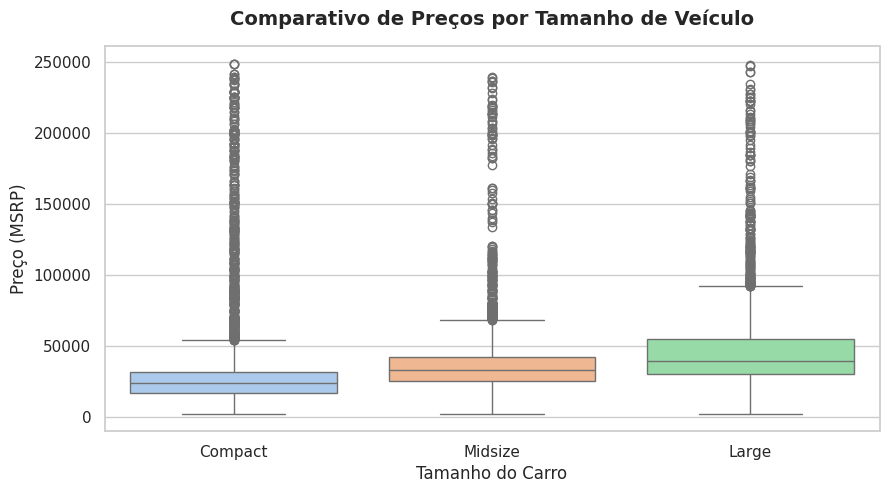

In [ ]:
# ==================== DIA 2: TRATAMENTO DE CHOQUE (LIMPEZA) ====================
print("\n=== INICIANDO DIA 2: LIMPEZA DOS DADOS ===")

print("\n1. Contagem de Valores Nulos (NaN) ANTES do tratamento:")
print(df.isna().sum()[df.isna().sum() > 0]) # Mostra apenas quem tem nulos

# Dropando market category porque ela é bem correlacionada com ...
df = df.drop(columns=['Market Category'])

df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())
df = df.dropna()

print("\n2. Contagem de Valores Nulos (NaN) DEPOIS do tratamento: Tudo zerado!")
print(df.isna().sum()[df.isna().sum() > 0])

# CORREÇÃO PANDAS 3.0: Remoção de duplicatas segura por atribuição
linhas_antes = df.shape[0]
print(f'Quantidade de linhas apos remoção de nulos',linhas_antes)
print(df[df.duplicated(keep=False)])
df = df.drop_duplicates()
print(f"\n3. Remoção de Duplicatas: {linhas_antes - df.shape[0]} linhas "
      f"clonadas eliminadas de forma segura.")

# --- GRÁFICO 4: BOXPLOT DE OUTLIERS COM LIMITE DE MERCADO ---
print("\nGerando Gráfico 4: Análise Estatística de Outliers...")
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['MSRP'], color='salmon', flierprops={"marker": "x", "markeredgecolor": "red"})
plt.title("Detecção de Outliers no Preço dos Carros (MSRP)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Preço (MSRP)", fontsize=12)
plt.show()

# Decisão de Negócio: Filtrando supercarros para focar no mercado comum
df = df[df['MSRP'] < 250000]
print(f"\nBase filtrada para carros normais (Abaixo de R$ 250.000). Novo tamanho: {df.shape[0]} linhas.")

# --- GRÁFICO 5 (NOVO!): BOXPLOT ESTILIZADO POR TAMANHO DE VEÍCULO ---
print("\nGerando Gráfico 5: Preço por Tamanho do Veículo (Sem Outliers extremos)...")
plt.figure(figsize=(10, 5))
# VALORIZAÇÃO: Boxplot categórico colorido para comparar subgrupos de dados
sns.boxplot(
    data=df,
    x='Vehicle Size',
    y='MSRP',
    hue='Vehicle Size',
    palette='pastel',
    legend=False
)
plt.title("Comparativo de Preços por Tamanho de Veículo", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tamanho do Carro", fontsize=12)
plt.ylabel("Preço (MSRP)", fontsize=12)
plt.show()

## Dia 3

In [ ]:
# ==============================================================================
# DIA 3: TRADUÇÃO PARA A MÁQUINA E PREVENÇÃO DE VAZAMENTO DE DADOS
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n=== INICIANDO DIA 3: ENGENHARIA DE RECURSOS ===")

# Removendo colunas de alta cardinalidade para simplificar a aula
df_reduzido = df.drop(columns=['Model', 'Engine Fuel Type', 'Vehicle Style'])

# ------------------------------------------------------------------------------
# 1. CODIFICAÇÃO ORDINAL (Quando a ordem importa)
# ------------------------------------------------------------------------------
print("\n1. Codificação Ordinal no 'Vehicle Size' (Compacto < Médio < Grande):")
# Criamos um dicionário definindo o peso de cada tamanho
dicionario_tamanho = {
    'Compact': 1,
    'Midsize': 2,
    'Large': 3
}
# A função map substitui o texto pelo número correspondente instantaneamente
df_reduzido['Vehicle Size'] = df_reduzido['Vehicle Size'].map(dicionario_tamanho)

print("Verificando se o texto virou número (1, 2 ou 3):")
display(df_reduzido['Vehicle Size'].value_counts())

# ------------------------------------------------------------------------------
# 2. DUMMIFICAÇÃO / ONE-HOT ENCODING (Para categorias sem hierarquia)
# ------------------------------------------------------------------------------
print("\n1. DUMMIFICAÇÃO (One-Hot Encoding):")
# drop_first=True elimina a redundância (tira o peso repetido que confunde a IA)
df_pronto = pd.get_dummies(df_reduzido, columns=['Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Make'], drop_first=True)
display(df_pronto.head(3))

print(f"Colunas saltaram para {df_pronto.shape[1]} após criar os 'interruptores' 0 e 1.")

# ------------------------------------------------------------------------------
# 3. PREVENÇÃO DE VAZAMENTO DE DADOS (Train-Test Split ANTES do Scaler)
# ------------------------------------------------------------------------------
print("\n3. Separando em Treino e Teste (Evitando Data Leakage):")
# Vamos prever o Preço (MSRP). O 'y' é o alvo, o 'X' é o resto.
X = df_pronto.drop(columns=['MSRP'])
y = df_pronto['MSRP']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dados de Treino: {X_treino.shape[0]} carros para a IA estudar.")
print(f"Dados de Teste: {X_teste.shape[0]} carros para a prova final.")

# ------------------------------------------------------------------------------
# 4. FEATURE SCALING (Padronização Matemática)
# ------------------------------------------------------------------------------
print("\n4. Aplicando o StandardScaler:")
# Só padronizamos as colunas que têm grandezas matemáticas grandes
colunas_para_escalar = ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity']

scaler = StandardScaler()

# ATENÇÃO ALUNOS: O scaler.fit() SÓ pode olhar para os dados de TREINO!
X_treino[colunas_para_escalar] = scaler.fit_transform(X_treino[colunas_para_escalar])

# Nos dados de teste, usamos apenas .transform() para não vazar a média do teste
X_teste[colunas_para_escalar] = scaler.transform(X_teste[colunas_para_escalar])

print("\nVisualizando as grandezas ajustadas (Média ~0, Desvio Padrão ~1):")
display(X_treino[colunas_para_escalar].head(3))

print("\nPROCESSO CONCLUÍDO! O Pipeline profissional foi aplicado com sucesso.")
print("A matriz X_treino e o alvo y_treino estão prontos para alimentar o algoritmo de IA!")


=== INICIANDO DIA 3: ENGENHARIA DE RECURSOS ===

1. Codificação Ordinal no 'Vehicle Size' (Compacto < Médio < Grande):
Verificando se o texto virou número (1, 2 ou 3):


,count
Vehicle Size,
1,4356
2,4062
3,2607



1. DUMMIFICAÇÃO (One-Hot Encoding):


,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP,Transmission Type_AUTOMATIC,Transmission Type_DIRECT_DRIVE,...,Make_Rolls-Royce,Make_Saab,Make_Scion,Make_Spyker,Make_Subaru,Make_Suzuki,Make_Tesla,Make_Toyota,Make_Volkswagen,Make_Volvo
0,2011,335.0,6.0,2.0,26,19,3916,46135,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2011,300.0,6.0,2.0,28,19,3916,40650,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,300.0,6.0,2.0,28,20,3916,36350,False,False,...,False,False,False,False,False,False,False,False,False,False


Colunas saltaram para 62 após criar os 'interruptores' 0 e 1.

3. Separando em Treino e Teste (Evitando Data Leakage):
Dados de Treino: 8820 carros para a IA estudar.
Dados de Teste: 2205 carros para a prova final.

4. Aplicando o StandardScaler:

Visualizando as grandezas ajustadas (Média ~0, Desvio Padrão ~1):


,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity
6803,-2.310379,-0.946343,-0.951294,-1.692401,-0.412755,-0.201711,-0.783369
9036,-1.481248,-0.229446,0.250426,-1.692401,-0.522696,-0.310053,-0.770914
2310,0.729767,-0.471641,-0.951294,0.615954,0.027012,0.014974,-0.705180



PROCESSO CONCLUÍDO! O Pipeline profissional foi aplicado com sucesso.
A matriz X_treino e o alvo y_treino estão prontos para alimentar o algoritmo de IA!
